In [1]:
# Presentation:
# - Multi-Object

In [2]:
# reloads modules before executing
%load_ext autoreload
%autoreload 2

In [4]:
from classes.particle_filter import ParticleFilter
from classes.particle_filter_multiple import MultiObjectParticleFilter
from classes.observation import TransitionModel, ObservationModel
from classes.simulator import create_ground_truth, generate_random_balls, create_ground_truth_n_balls
from classes.plotting import plot_sim_n_balls_point_prediction, plot_particles_at_time, animate_particle_filter
from classes.evaluator import get_stats
from classes.tester import create_test_scenario, ParticleFilterTester, run_one_test
import numpy as np

Running test: 


/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:136: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


Saving plot to results/.png
Animating particle filter...


ValueError: unknown file extension: 

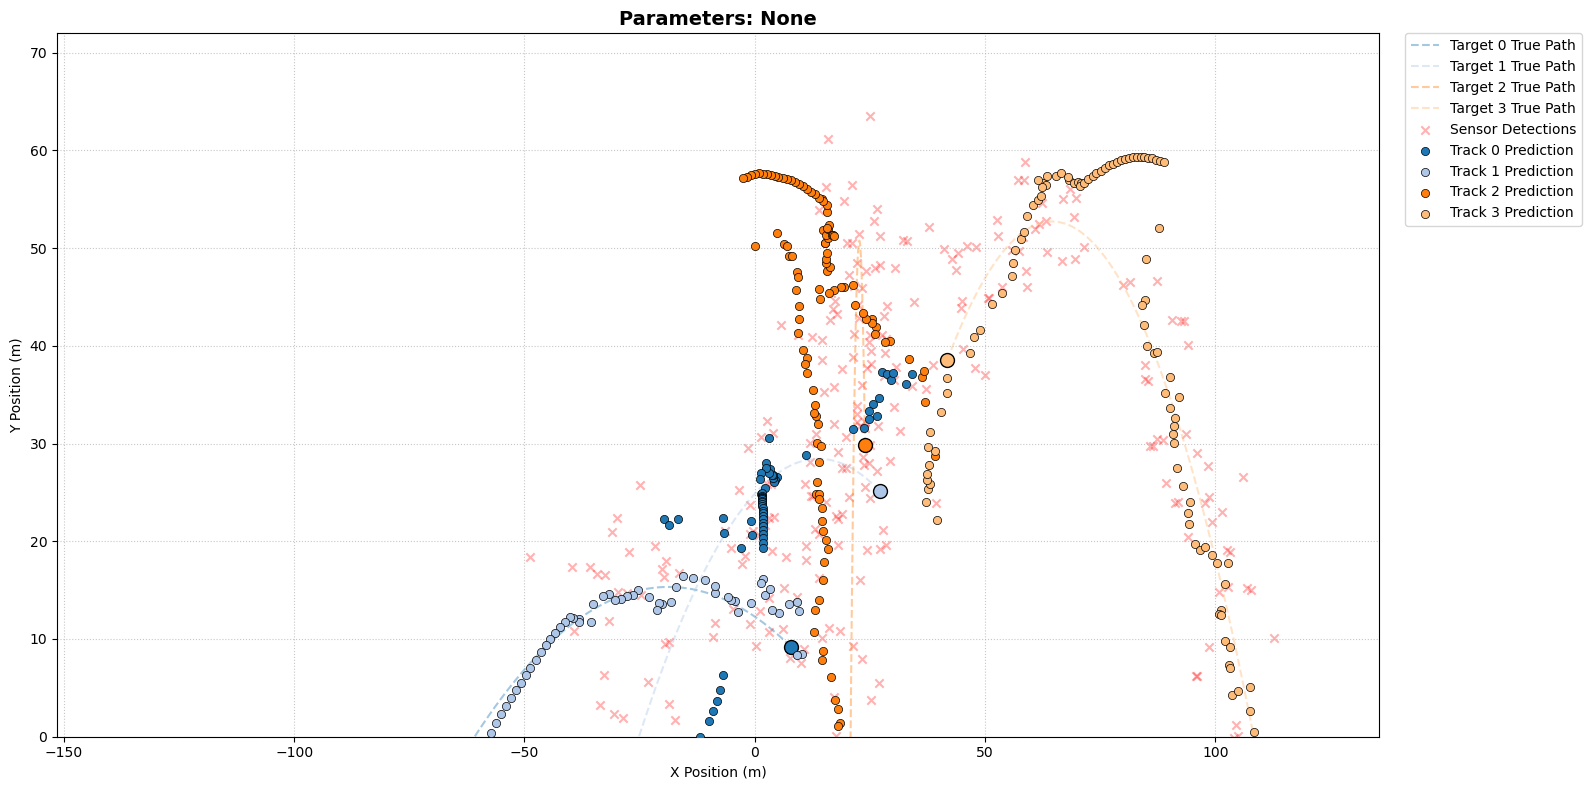

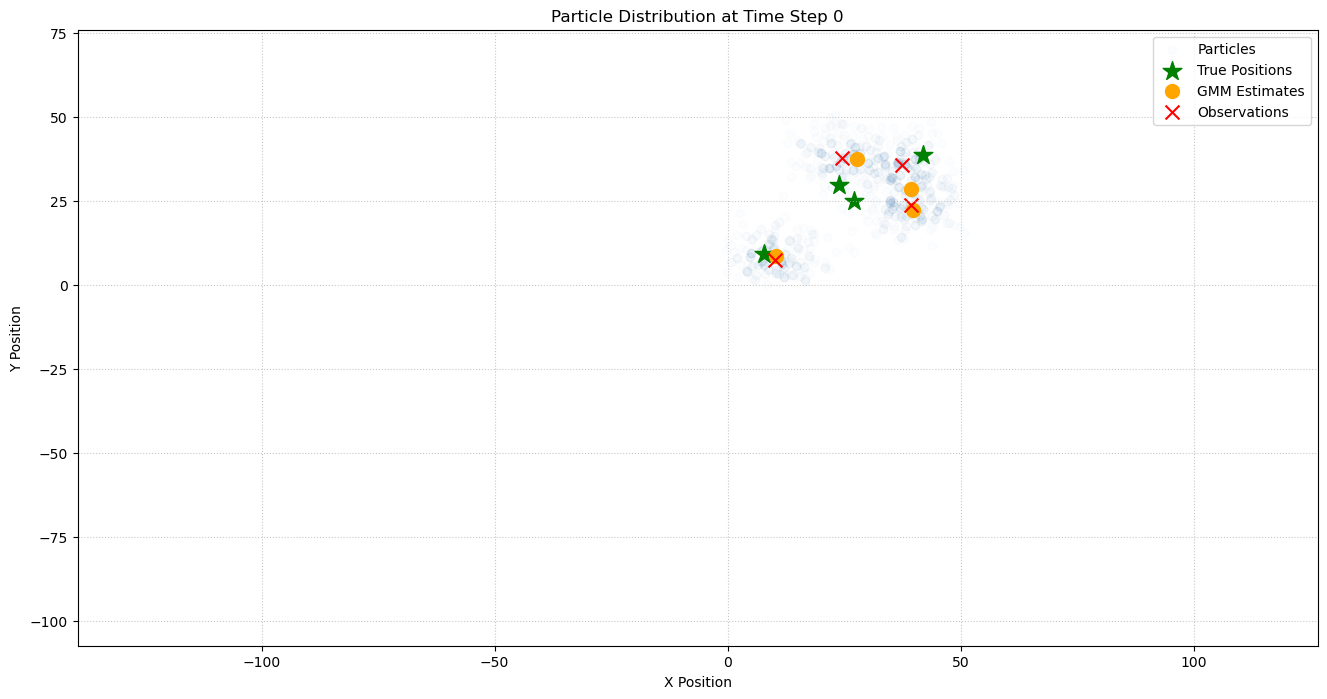

In [6]:
seed = 5

STATE_BOUNDS = [
    (0.0, 50.0),    # x bounds
    (0.0, 50.0),    # y bounds
    (-30.0, 30.0),  # vx bounds
    (0.0, 40.0)     # vy bounds
]

# Simulation Parameters
dropout_start = 40
dropout_end = 60
process_noise = 0.5
measurement_noise = 25


# Same Starting Position, different y_velocities
# true_states = np.array([
#     [20.0, 20.0, 2.0, 10.0],
#     [20.0, 20.0, 2.0, 12.0],
#     [20.0, 20.0, 2.0, 14.0],
#     [20.0, 20.0, 2.0, 16.0],
#     [20.0, 20.0, 2.0, 18.0],
#     [20.0, 20.0, 2.0, 20.0],
#     [20.0, 20.0, 2.0, 22.0],
# ], dtype=float)

# Crossing Each Other
# true_states = np.array([
#     [20.0, 20.0, 2.0, 25.0],
#     [20.0, 20.0, 2.0, 30.0],
#     [30.0, 20.0, -2.0, 25.0],
#     [30.0, 20.0, -2.0, 30.0]
# ], dtype=float)


# A LOT of balls:
true_states = generate_random_balls(num_balls=4, state_bounds=STATE_BOUNDS)

n_objects = len(true_states)

# Build the ground truth + observations ONCE, before the filter runs --
# both assignment methods get tested against the exact same observation
# sequence, so any difference in results is purely due to the assignment
# strategy, not different noise draws.

# Particle Filter Parameters
num_particles_per_ball = 1000

input_parameters = {
    # Parameters for the balls
    "true_states": true_states,
    "dropout_start": dropout_start,
    "dropout_end": dropout_end,
    "process_noise": process_noise,
    "measurement_noise": measurement_noise,

    # Parameters for the Filter
    "num_particles": num_particles_per_ball,
    "state_bounds": STATE_BOUNDS,
    "init_generator": "Sobol",
    "use_velocity_likelihood": True,
    "velocity_sigma": 10.0,
    "min_velocity_likelihood": 0.01,
    "neighbor_assignment": "Hungarian",
    'ess_resample_threshold': 0.9
}

tester = ParticleFilterTester(input_parameters, save_dir="results", model="SingleParticleFilter")


results = tester.sweep_multi({
    #"use_velocity_likelihood": [True, False],
}, mode="grid", seed=seed)
results

In [5]:
n_objects = 5
step_size = 0.05
num_steps = 120
dropout_start = -1
dropout_end = -1
process_noise = 1

measurement_noise = 1000

STATE_BOUNDS = [
    (0.0, 50.0),    # x bounds
    (0.0, 50.0),    # y bounds
    (-30.0, 30.0),  # vx bounds
    (0.0, 40.0)     # vy bounds
]


num_particles = 1000
init_generator = "Sobol"


# Crossing Each Other
# true_states_multi = np.array([
#     [20.0, 20.0, 2.0, 25.0],
#     [20.0, 20.0, 2.0, 30.0],
#     [30.0, 20.0, -2.0, 25.0],
#     [30.0, 20.0, -2.0, 30.0]
# ], dtype=float)

# Similar Trajectories
# true_states_multi = np.array([
#     [5.0, 5.0, 18.0, 25.0],
#     [5.0, 5.0, 18.0, 30.0],
#     [5.0, 5.0, 18.0, 35.0],
#     [5.0, 5.0, 18.0, 40.0]
# ], dtype=float)

# Create multi-ball physics models
true_states_multi = generate_random_balls(n_objects, STATE_BOUNDS)

transition_model = TransitionModel(delta_t=step_size, process_noise=1)

observation_model = ObservationModel("Gaussian", measurement_noise=measurement_noise)
model_transition_model = TransitionModel(delta_t=step_size, process_noise=process_noise)

# Generate multi-ball paths and sensor reads
true_trajectory_multi, observations_multi = create_ground_truth_n_balls(
    num_steps, dropout_start, dropout_end, true_states_multi, transition_model, observation_model
)

# Initialize Particle Filter with expanded particle cloud for multi-modality
pf_multi = MultiObjectParticleFilter(
    num_particles=num_particles,
    n_balls=n_objects,
    state_bounds=STATE_BOUNDS,
    transition_model=model_transition_model,
    observation_model=observation_model,
    init_generator=init_generator,
)

# pf_single = ParticleFilter(
#     num_particles=num_particles * n_objects,  # more particles to equalize playing field
#     state_bounds=state_bounds,
#     transition_model=model_transition_model,
#     observation_model=observation_model,
#     init_generator=init_generator,
#     roughening_noise=roughening_noise
# )

# Run the tracking engine
history_multi = pf_multi.run(observations_multi)

# history_single = pf_single.run(observations_multi, n_objects=n_objects)


c:\THWS\THWS\1. Semester\RDM\New_Particle_Filter\classes\particle_filter_multiple.py:117: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


In [6]:
# plot_sim_n_balls_point_prediction(
#     true_trajectory_multi,
#     observations_multi,
#     history_single,
#     dropout_start,
#     dropout_end
# )

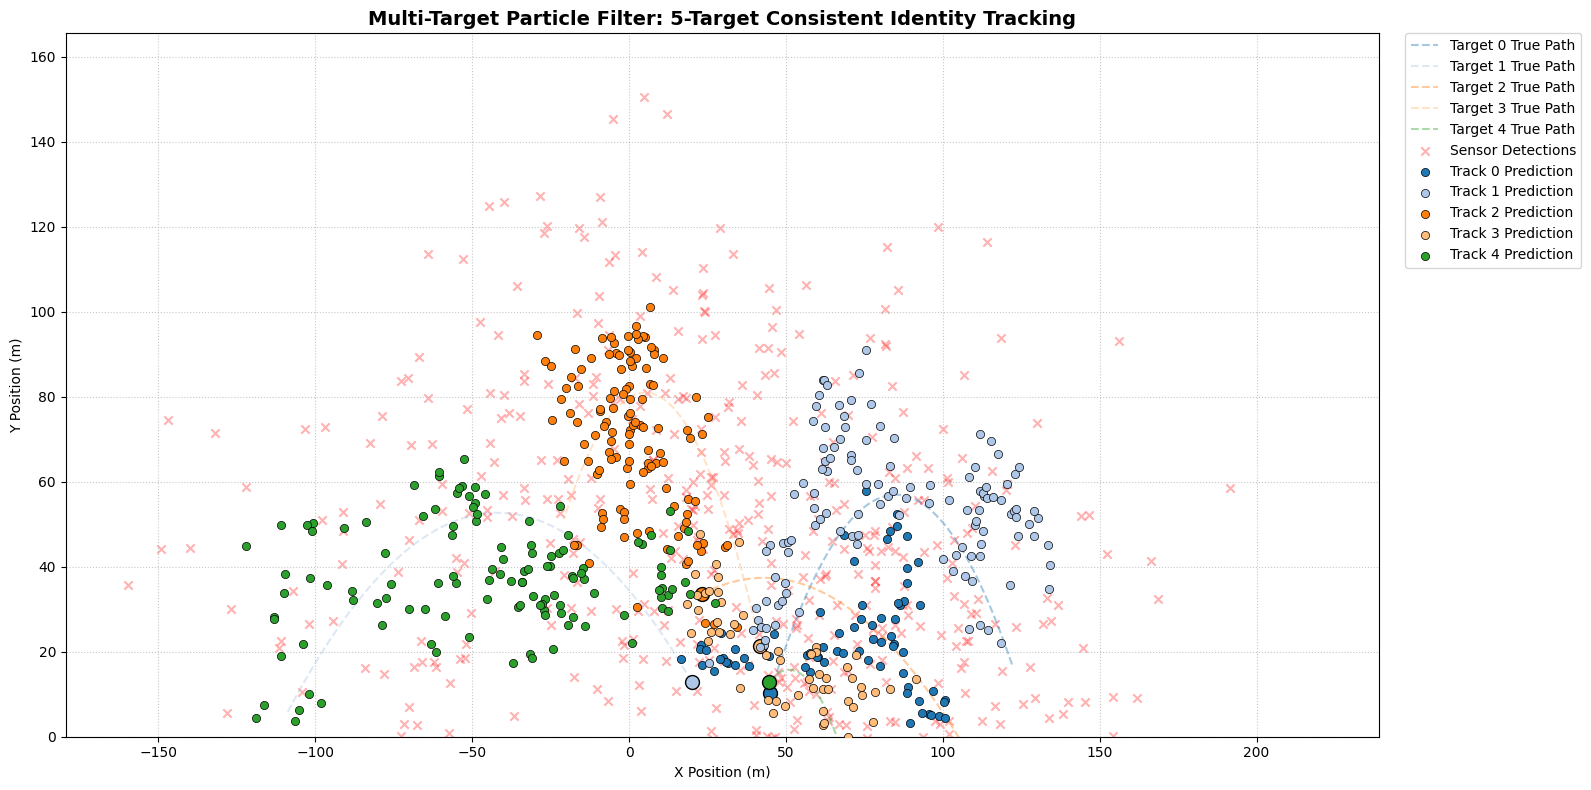

In [7]:
plot_sim_n_balls_point_prediction(
    true_trajectory_multi,
    observations_multi,
    history_multi,
    dropout_start,
    dropout_end
)

In [8]:
# animate_particle_filter(true_trajectory_multi, history_multi, save_path="particle_filter_multiple_animation.gif")
# animate_particle_filter(true_trajectory_multi, history_single, save_path="particle_filter_single_animation.gif")


In [9]:
# from PIL import Image
# import io
# import ipywidgets as widgets
# from IPython.display import display

# # load frames from GIF
# gif_path = "particle_filter_multiple_animation.gif"
# pil = Image.open(gif_path)
# frames_bytes = []
# try:
#     i = 0
#     while True:
#         pil.seek(i)
#         buf = io.BytesIO()
#         pil.convert("RGBA").save(buf, format="PNG")
#         frames_bytes.append(buf.getvalue())
#         i += 1
# except EOFError:
#     pass

# # widgets
# img = widgets.Image(value=frames_bytes[0], format='png', width=640*2, height=480*2)
# slider = widgets.IntSlider(min=0, max=len(frames_bytes)-1, description='Frame')
# play = widgets.Play(min=0, max=len(frames_bytes)-1, interval=200)

# widgets.jslink((play, 'value'), (slider, 'value'))

# def on_frame_change(change):
#     img.value = frames_bytes[change['new']]

# slider.observe(on_frame_change, names='value')

# controls = widgets.HBox([play, slider])
# display(controls, img)

In [10]:
# from PIL import Image
# import io
# import ipywidgets as widgets
# from IPython.display import display

# # load frames from GIF
# gif_path = "particle_filter_single_animation.gif"
# pil = Image.open(gif_path)
# frames_bytes = []
# try:
#     i = 0
#     while True:
#         pil.seek(i)
#         buf = io.BytesIO()
#         pil.convert("RGBA").save(buf, format="PNG")
#         frames_bytes.append(buf.getvalue())
#         i += 1
# except EOFError:
#     pass

# # widgets
# img = widgets.Image(value=frames_bytes[0], format='png', width=640*2, height=480*2)
# slider = widgets.IntSlider(min=0, max=len(frames_bytes)-1, description='Frame')
# play = widgets.Play(min=0, max=len(frames_bytes)-1, interval=200)

# widgets.jslink((play, 'value'), (slider, 'value'))

# def on_frame_change(change):
#     img.value = frames_bytes[change['new']]

# slider.observe(on_frame_change, names='value')

# controls = widgets.HBox([play, slider])
# display(controls, img)

In [11]:

get_stats(true_trajectory_multi, observations_multi, history_multi, num_steps)
# print_stats(true_trajectory_multi, observations_multi, history_single, num_steps)

{'est_mean_error': np.float64(11.64741717730422),
 'est_rmse': np.float64(12.641981556195505),
 'obs_mean_error': np.float64(12.608677280256002),
 'obs_rmse': np.float64(13.621616857203048)}